In [19]:
import os, pickle, re
from pathlib import Path
from real_data import vendors, vendor_map, get_initial_state
from adoptionopinions_model import Simulation, Networks, Initial_state
from networks import complete
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
real_world_data = "vendor-ww-monthly-201407-202605.csv"
n = 1000
model_path = f"best_model/best_model_{n}.pkl"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
df = pd.read_csv(real_world_data)
df = df[vendors] / 100

best_model/best_model_1000.pkl


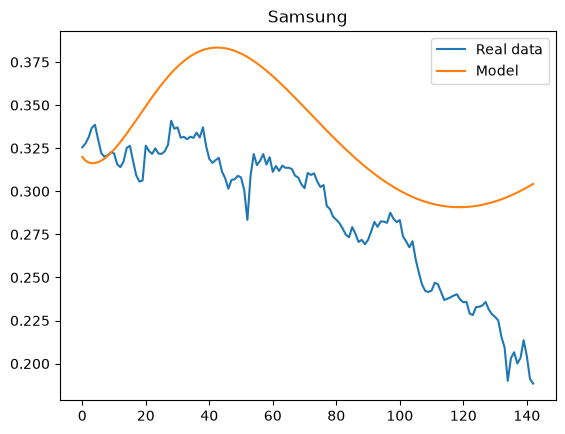

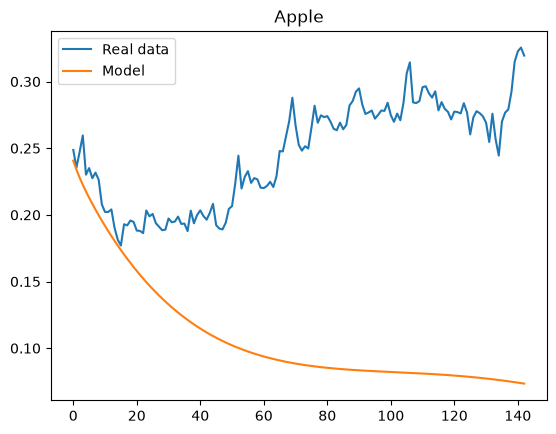

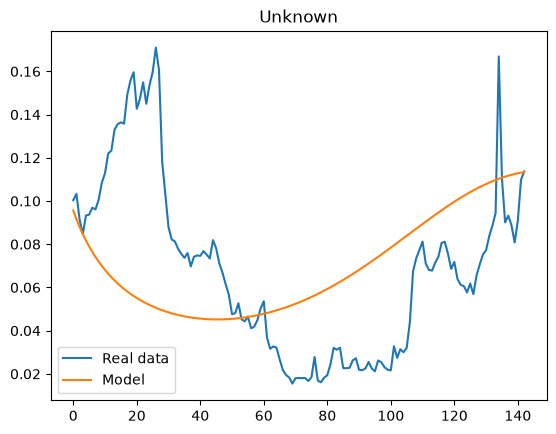

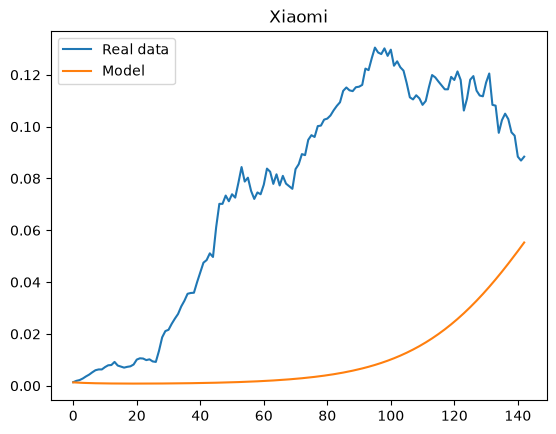

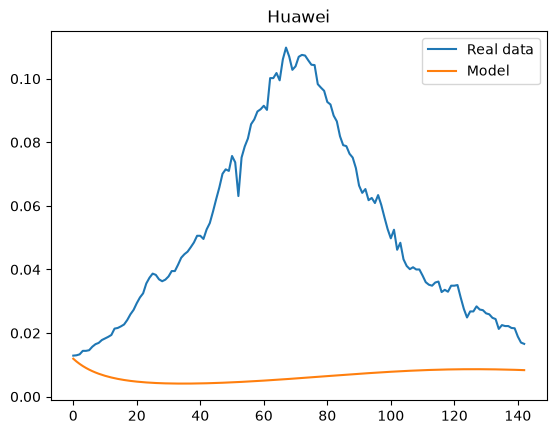

In [23]:
with open(model_path, "rb") as fd:
    print(model_path)
    SC = pickle.load(fd)

k = len(vendors)
rows = len(df)
IS = get_initial_state(n, df.iloc[0].tolist(), k)
IS = Initial_state(IS.s, IS.a, IS.d, SC.x0)
net = Networks(W=complete(n), V = complete(n))

sim = Simulation(
            simulation_constants = SC,
            initial_states = IS,
            net = net,
            window_size=rows
            )

for _ in range(rows):
    sim()

# the shape of the object is: rows * k * n
states = sim.get_adoption_states()
market_share_prediction = [None] * k
for vendor in vendors:
    index = vendor_map[vendor]
    # market_share_prediction is a row long list of the mean of the k:th vendor.
    # rows * 1 * n -> rows * 1
    market_share_prediction[index] = np.array([state[index].mean() for state in states])

o = rows

for vendor in vendors:
    index = vendor_map[vendor]
    plt.plot(df[vendor], label="Real data")
    plt.plot(market_share_prediction[index][:o], label="Model")
    plt.title(vendor)
    
    plt.legend()
    plt.show()
